# Pair-image COMFORT MCQ Analysis

This notebook automatically loads all `pair_mcq_{length}_{model}.csv` files generated with `--pair_mode`. Each row contains two images of the same scene from different camera views.

Expected complete pair runs have 216 rows: 9 objects x 4 relations x C(4 camera views, 2).

In [1]:
import os
import re
import glob
import sys
import csv
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

csv.field_size_limit(sys.maxsize)

BASE_DIR = "."
LENGTHS = ["short", "middle", "long"]
RELATIONS = ["front", "behind", "left", "right"]
VIEW_SHORT = ["back", "front", "left", "right"]
VIEW_PAIRS_ORDERED = [
    ("back", "front"),
    ("back", "left"),
    ("back", "right"),
    ("front", "left"),
    ("front", "right"),
    ("left", "right"),
]
MODEL_ORDER = [
    "internvl",
    "internvl_thinking",
    "qwen3vl",
    "qwen3vl_thinking",
    "qwen3_5vl",
    "qwen3_5vl_thinking",
    "gemma4",
    "gemma4_thinking",
]
RELATION_MAP = {
    "infrontof": "front",
    "totheleft": "left",
    "totheright": "right",
    "behind": "behind",
}
OBJECT_POSITIONS = ["left", "right", "front", "behind"]

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_rows", 240)
pd.set_option("display.max_columns", 100)

EXAMPLE_IMAGES = {
    "left": "/home/zzou/COMFORT/data/comfort_human_car/totheleft/bicycle__totheleft__cam_back/0.png",
    "right": "/home/zzou/COMFORT/data/comfort_human_car/totheright/bicycle__totheright__cam_back/0.png",
    "front": "/home/zzou/COMFORT/data/comfort_human_car/behind/bicycle__behind__cam_back/0.png",
    "behind": "/home/zzou/COMFORT/data/comfort_human_car/infrontof/bicycle__infrontof__cam_back/0.png",
}


def ordered_models(models):
    known = [m for m in MODEL_ORDER if m in models]
    extra = sorted(m for m in models if m not in MODEL_ORDER)
    return known + extra


def parse_result_filename(path, prefix="pair_mcq"):
    name = os.path.basename(path)
    pattern = rf"^{prefix}_(short|middle|long)_(.+)\.csv$"
    m = re.match(pattern, name)
    if not m:
        return None
    return m.group(2), m.group(1)


def discover_result_files(prefix="pair_mcq"):
    found = {}
    for path in sorted(glob.glob(os.path.join(BASE_DIR, f"{prefix}_*.csv"))):
        parsed = parse_result_filename(path, prefix=prefix)
        if parsed is None:
            continue
        model, length = parsed
        # Exclude ad-hoc prompt variants from the main matrix unless renamed into the standard model list.
        if model.endswith("_newprompt"):
            continue
        found[(model, length)] = path
    return found


def extract_letter_to_relation(prompt):
    prompt = str(prompt)
    mapping = {}
    for letter in ["A", "B", "C", "D"]:
        pattern = rf"{letter}\.\s*(.*?)(?=(?:A|B|C|D)\.\s|$)"
        m = re.search(pattern, prompt, flags=re.IGNORECASE | re.DOTALL)
        if not m:
            continue
        text = m.group(1).lower()
        if "front" in text:
            mapping[letter] = "front"
        elif "behind" in text:
            mapping[letter] = "behind"
        elif "left" in text:
            mapping[letter] = "left"
        elif "right" in text:
            mapping[letter] = "right"
    return mapping


def extract_comfort_path_info(image_path):
    image_path = str(image_path)
    parts = os.path.dirname(image_path).split("/")
    raw_relation = parts[-2]
    folder_name = parts[-1]
    segments = folder_name.split("__")
    obj = segments[0] if segments else None
    cam_segment = segments[-1] if segments else ""
    camera_position = cam_segment.split("_")[-1]

    camera_perspective = None
    if (raw_relation == "behind" and camera_position == "left") or (raw_relation == "infrontof" and camera_position == "right") or (raw_relation == "totheleft" and camera_position == "front") or (raw_relation == "totheright" and camera_position == "back"):
        camera_perspective = "right"
    elif (raw_relation == "behind" and camera_position == "right") or (raw_relation == "infrontof" and camera_position == "left") or (raw_relation == "totheleft" and camera_position == "back") or (raw_relation == "totheright" and camera_position == "front"):
        camera_perspective = "left"
    elif (raw_relation == "behind" and camera_position == "front") or (raw_relation == "infrontof" and camera_position == "back") or (raw_relation == "totheleft" and camera_position == "right") or (raw_relation == "totheright" and camera_position == "left"):
        camera_perspective = "behind"
    elif (raw_relation == "behind" and camera_position == "back") or (raw_relation == "infrontof" and camera_position == "front") or (raw_relation == "totheleft" and camera_position == "left") or (raw_relation == "totheright" and camera_position == "right"):
        camera_perspective = "front"

    return {
        "raw_relation": raw_relation,
        "object": obj,
        "cam_short": camera_position,
        "camera_perspective": camera_perspective,
    }


def load_and_prepare_pair(csv_path):
    df = pd.read_csv(csv_path)
    if len(df) == 0:
        return df

    letter_maps = df["mcq_prompt"].apply(extract_letter_to_relation)
    df["pred_letter_clean"] = df["pred_letter"].astype(str).str.strip().str.upper().str.extract(r"([ABCD])", expand=False)
    df["correct_letter_clean"] = df["correct_letter"].astype(str).str.strip().str.upper().str.extract(r"([ABCD])", expand=False)
    df["opposite_letter_clean"] = df["opposite_letter"].astype(str).str.strip().str.upper().str.extract(r"([ABCD])", expand=False)
    df["pred_relation"] = [m.get(l, None) for m, l in zip(letter_maps, df["pred_letter_clean"])]
    df["correct_relation"] = df["correct_relation"].astype(str).str.strip().str.lower().replace(RELATION_MAP)
    df["opposite_relation"] = df["opposite_relation"].astype(str).str.strip().str.lower().replace(RELATION_MAP)
    df["is_correct"] = df["pred_letter_clean"] == df["correct_letter_clean"]
    df["is_opposite"] = df["pred_letter_clean"] == df["opposite_letter_clean"]
    df["has_valid_pred"] = df["pred_relation"].isin(RELATIONS)

    r1 = df["image_path_1"].apply(extract_comfort_path_info).apply(pd.Series)
    r2 = df["image_path_2"].apply(extract_comfort_path_info).apply(pd.Series)
    df["object_position"] = r1["raw_relation"].replace(RELATION_MAP)
    df["object"] = r1["object"]
    df["cam_perspective_1"] = r1["camera_perspective"]
    df["cam_perspective_2"] = r2["camera_perspective"]
    df["cam_view_1"] = df["cam_view_1"].astype(str).str.strip()
    df["cam_view_2"] = df["cam_view_2"].astype(str).str.strip()
    df["view1_short"] = df["cam_view_1"].str.replace("cam_", "", regex=False)
    df["view2_short"] = df["cam_view_2"].str.replace("cam_", "", regex=False)
    df["view_pair"] = df["view1_short"] + " x " + df["view2_short"]
    return df


def load_single(csv_path):
    df = pd.read_csv(csv_path)
    if len(df) == 0:
        return df
    letter_maps = df["mcq_prompt"].apply(extract_letter_to_relation)
    df["pred_letter_clean"] = df["pred_letter"].astype(str).str.strip().str.upper().str.extract(r"([ABCD])", expand=False)
    df["correct_letter_clean"] = df["correct_letter"].astype(str).str.strip().str.upper().str.extract(r"([ABCD])", expand=False)
    df["opposite_letter_clean"] = df["opposite_letter"].astype(str).str.strip().str.upper().str.extract(r"([ABCD])", expand=False)
    df["pred_relation"] = [m.get(l, None) for m, l in zip(letter_maps, df["pred_letter_clean"])]
    df["correct_relation"] = df["correct_relation"].astype(str).str.strip().str.lower().replace(RELATION_MAP)
    df["is_correct"] = df["pred_letter_clean"] == df["correct_letter_clean"]
    df["is_opposite"] = df["pred_letter_clean"] == df["opposite_letter_clean"]
    return df


def summarize_pair(df, model, length, csv_path):
    if len(df) == 0:
        return {"model": model, "length": length, "rows": 0, "accuracy": np.nan, "opposite_rate": np.nan, "valid_pred_rate": np.nan, "csv": os.path.basename(csv_path), "complete_216": False}
    return {
        "model": model,
        "length": length,
        "rows": len(df),
        "accuracy": df["is_correct"].mean(),
        "opposite_rate": df["is_opposite"].mean(),
        "valid_pred_rate": df["has_valid_pred"].mean(),
        "csv": os.path.basename(csv_path),
        "complete_216": len(df) == 216,
    }


def relation_breakdown(df, model, length):
    rows = []
    for rel in RELATIONS:
        sub = df[df["correct_relation"] == rel]
        rows.append({
            "model": model,
            "length": length,
            "relation": rel,
            "n": len(sub),
            "accuracy": sub["is_correct"].mean() if len(sub) else np.nan,
            "opposite_rate": sub["is_opposite"].mean() if len(sub) else np.nan,
        })
    return rows


def plot_confusion_on_ax(df, ax, title, true_labels=RELATIONS):
    plot_df = df[df["correct_relation"].isin(true_labels) & df["pred_relation"].isin(RELATIONS)].copy()
    if len(plot_df) == 0:
        ax.axis("off")
        ax.set_title(f"{title}\n(no data)")
        return
    cm_df = pd.crosstab(plot_df["correct_relation"], plot_df["pred_relation"], normalize="index").reindex(index=true_labels, columns=RELATIONS, fill_value=0.0)
    sns.heatmap(cm_df, ax=ax, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, cbar=False)
    ax.set_title(title)
    ax.set_xlabel("predicted")
    ax.set_ylabel("true")

print("Helpers loaded.")

Helpers loaded.


## 1. Load All Pair CSVs

In [2]:
files = discover_result_files(prefix="pair_mcq")
all_dfs = defaultdict(dict)
summary_rows = []
relation_rows = []

for model in ordered_models({m for m, _ in files}):
    for length in LENGTHS:
        path = files.get((model, length))
        if path is None:
            continue
        df = load_and_prepare_pair(path)
        if len(df) == 0:
            print(f"Skip empty file: {os.path.basename(path)}")
            continue
        all_dfs[model][length] = df
        summary_rows.append(summarize_pair(df, model, length, path))
        relation_rows.extend(relation_breakdown(df, model, length))

summary_df = pd.DataFrame(summary_rows)
relation_df = pd.DataFrame(relation_rows)
models = ordered_models(all_dfs.keys())

print(f"Loaded {len(summary_df)} non-empty pair result files.")
display(summary_df.sort_values(["model", "length"]).reset_index(drop=True))

missing = []
for model in MODEL_ORDER:
    for length in LENGTHS:
        if (model, length) not in files:
            missing.append({"model": model, "length": length, "expected_csv": f"pair_mcq_{length}_{model}.csv"})
missing_df = pd.DataFrame(missing)
print("Missing expected files:")
display(missing_df if len(missing_df) else pd.DataFrame([{"status": "none"}]))

Loaded 22 non-empty pair result files.


,model,length,rows,accuracy,opposite_rate,valid_pred_rate,csv,complete_216
0,gemma4,long,216,0.259259,0.356481,1.000000,pair_mcq_long_gemma4.csv,True
1,gemma4,middle,216,0.337963,0.291667,1.000000,pair_mcq_middle_gemma4.csv,True
2,gemma4,short,216,0.287037,0.222222,0.967593,pair_mcq_short_gemma4.csv,True
3,gemma4_thinking,long,216,0.212963,0.287037,1.000000,pair_mcq_long_gemma4_thinking.csv,True
4,gemma4_thinking,middle,216,0.203704,0.236111,1.000000,pair_mcq_middle_gemma4_thinking.csv,True
5,gemma4_thinking,short,216,0.212963,0.305556,1.000000,pair_mcq_short_gemma4_thinking.csv,True
6,gpt_5,long,216,0.592593,0.064815,1.000000,pair_mcq_long_gpt_5.csv,True
7,gpt_5_thinking,long,215,0.609302,0.051163,1.000000,pair_mcq_long_gpt_5_thinking.csv,False
8,internvl,long,216,0.199074,0.245370,1.000000,pair_mcq_long_internvl.csv,True
9,internvl,middle,216,0.254630,0.259259,1.000000,pair_mcq_middle_internvl.csv,True


Missing expected files:


,model,length,expected_csv
0,internvl_thinking,short,pair_mcq_short_internvl_thinking.csv
1,internvl_thinking,middle,pair_mcq_middle_internvl_thinking.csv
2,qwen3vl_thinking,short,pair_mcq_short_qwen3vl_thinking.csv
3,qwen3vl_thinking,middle,pair_mcq_middle_qwen3vl_thinking.csv


## 2. Overall Pair Accuracy

length,short,middle,long
model,,,
internvl,0.199,0.255,0.199
internvl_thinking,NaN,NaN,0.218
qwen3vl,0.231,0.241,0.245
qwen3vl_thinking,NaN,NaN,0.227
qwen3_5vl,0.198,0.154,0.284
qwen3_5vl_thinking,0.510,1.000,0.571
gemma4,0.287,0.338,0.259
gemma4_thinking,0.213,0.204,0.213
gpt_5,NaN,NaN,0.593


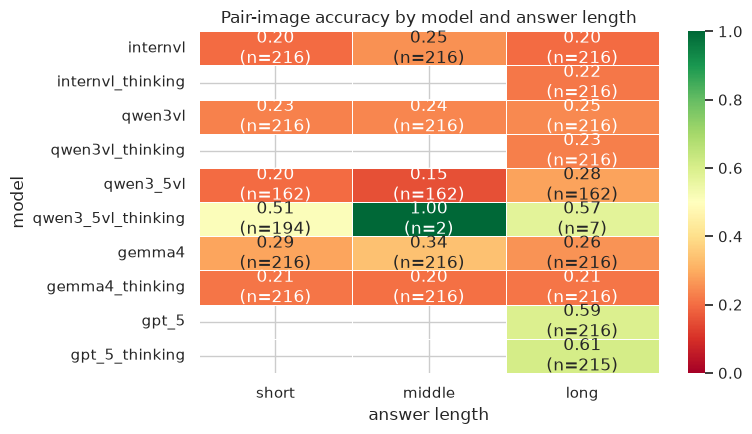

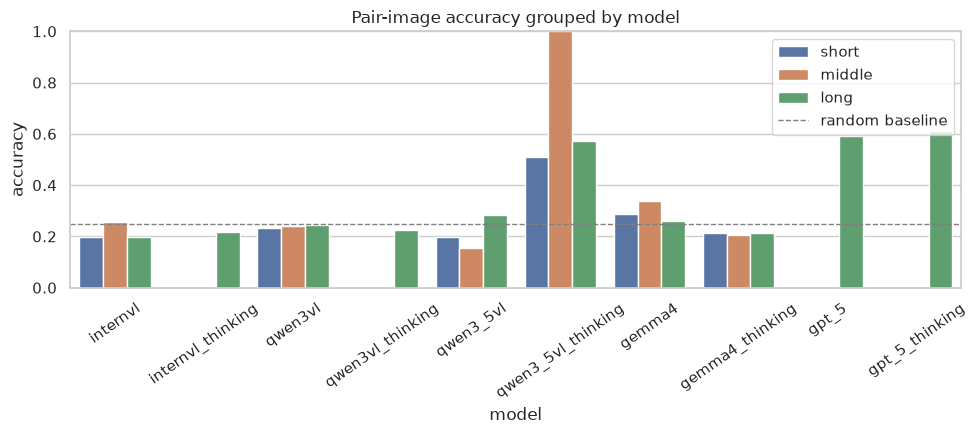

In [3]:
if len(summary_df):
    acc_pivot = summary_df.pivot(index="model", columns="length", values="accuracy").reindex(index=models, columns=LENGTHS)
    n_pivot = summary_df.pivot(index="model", columns="length", values="rows").reindex(index=models, columns=LENGTHS)
    display(acc_pivot.round(3))

    annot = acc_pivot.copy().astype(object)
    for model in acc_pivot.index:
        for length in acc_pivot.columns:
            acc = acc_pivot.loc[model, length]
            n = n_pivot.loc[model, length]
            annot.loc[model, length] = "" if pd.isna(acc) else f"{acc:.2f}\n(n={int(n)})"

    fig, ax = plt.subplots(figsize=(8, max(3, 0.45 * len(models))))
    sns.heatmap(acc_pivot, annot=annot, fmt="", cmap="RdYlGn", vmin=0, vmax=1, linewidths=0.5, ax=ax)
    ax.set_title("Pair-image accuracy by model and answer length")
    ax.set_xlabel("answer length")
    ax.set_ylabel("model")
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(10, 4.5))
    sns.barplot(data=summary_df, x="model", y="accuracy", hue="length", hue_order=LENGTHS, order=models, ax=ax)
    ax.axhline(0.25, color="gray", linestyle="--", linewidth=1, label="random baseline")
    ax.set_ylim(0, 1)
    ax.set_title("Pair-image accuracy grouped by model")
    ax.tick_params(axis="x", rotation=35)
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

## 3. Accuracy and Opposite Error by True Relation

,model,length,relation,n,accuracy,opposite_rate
0,gemma4,long,behind,54,0.204,0.333
1,gemma4,long,front,54,0.333,0.222
2,gemma4,long,left,54,0.333,0.370
3,gemma4,long,right,54,0.167,0.500
4,gemma4,middle,behind,54,0.278,0.278
5,gemma4,middle,front,54,0.241,0.185
6,gemma4,middle,left,54,0.315,0.407
7,gemma4,middle,right,54,0.519,0.296
8,gemma4,short,behind,54,0.093,0.333
9,gemma4,short,front,54,0.352,0.259


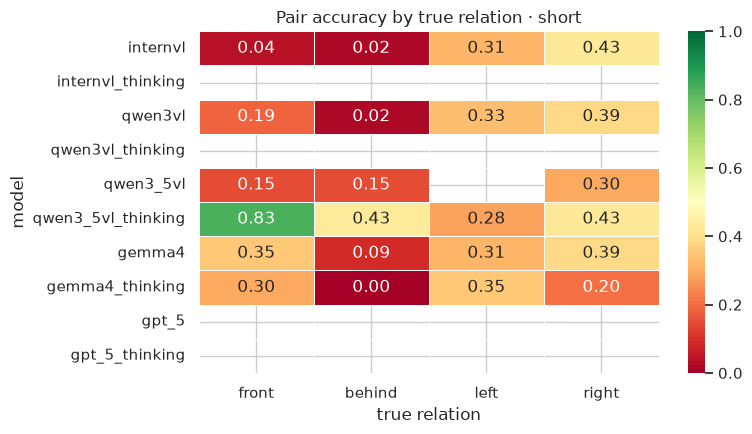

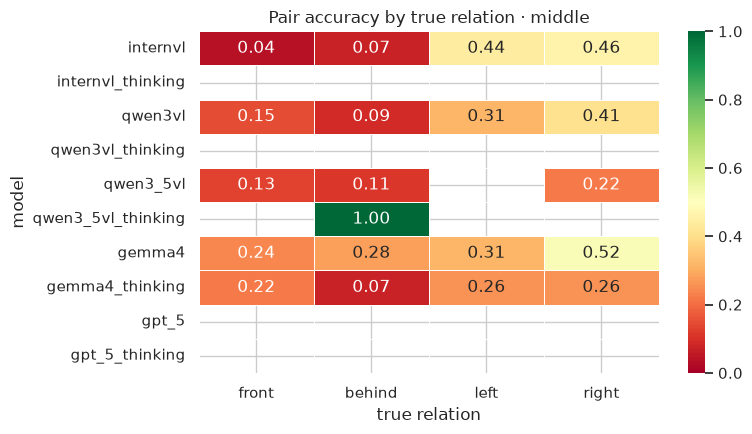

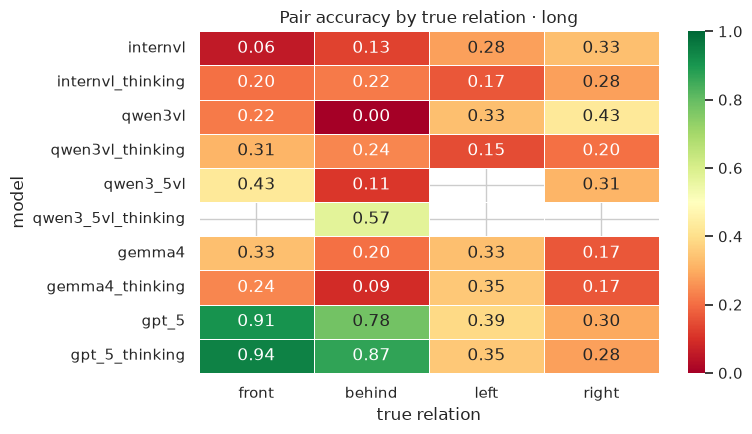

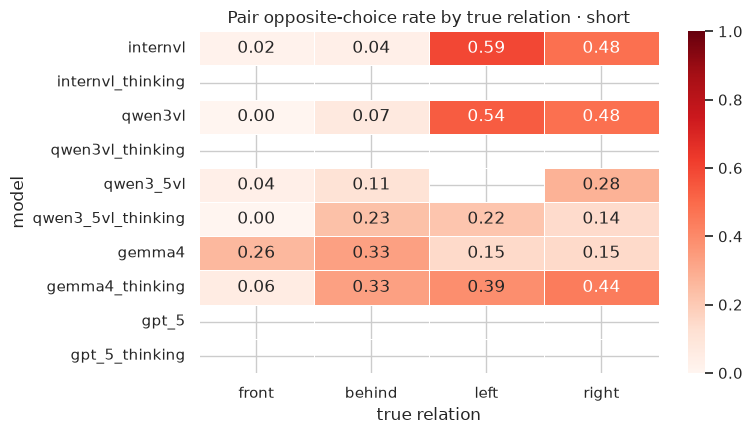

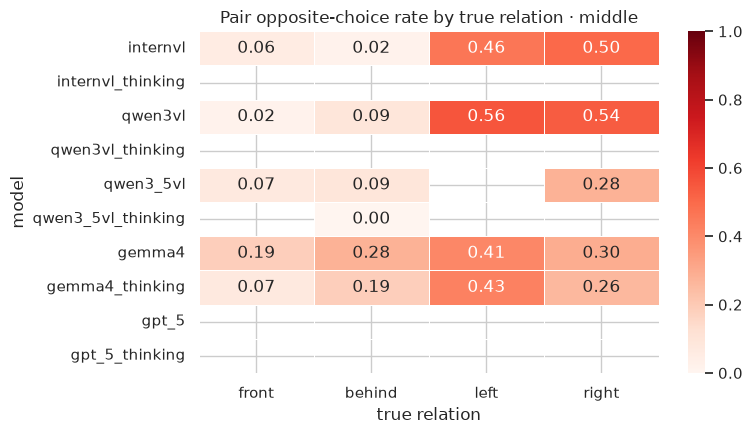

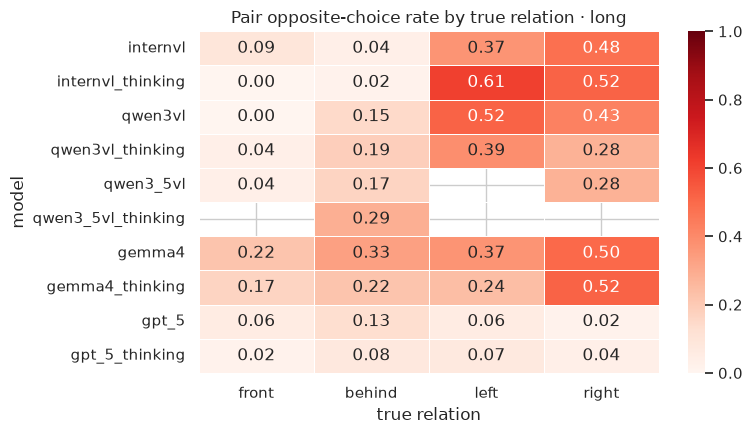

In [4]:
if len(relation_df):
    display(relation_df.sort_values(["model", "length", "relation"]).round(3).reset_index(drop=True))

    for metric, title, cmap in [
        ("accuracy", "Pair accuracy by true relation", "RdYlGn"),
        ("opposite_rate", "Pair opposite-choice rate by true relation", "Reds"),
    ]:
        for length in LENGTHS:
            sub = relation_df[relation_df["length"] == length]
            if len(sub) == 0:
                continue
            pivot = sub.pivot(index="model", columns="relation", values=metric).reindex(index=models, columns=RELATIONS)
            fig, ax = plt.subplots(figsize=(8, max(3, 0.45 * len(models))))
            sns.heatmap(pivot, annot=True, fmt=".2f", cmap=cmap, vmin=0, vmax=1, linewidths=0.5, ax=ax)
            ax.set_title(f"{title} · {length}")
            ax.set_xlabel("true relation")
            ax.set_ylabel("model")
            plt.tight_layout()
            plt.show()

## 4. Confusion Matrices by Model

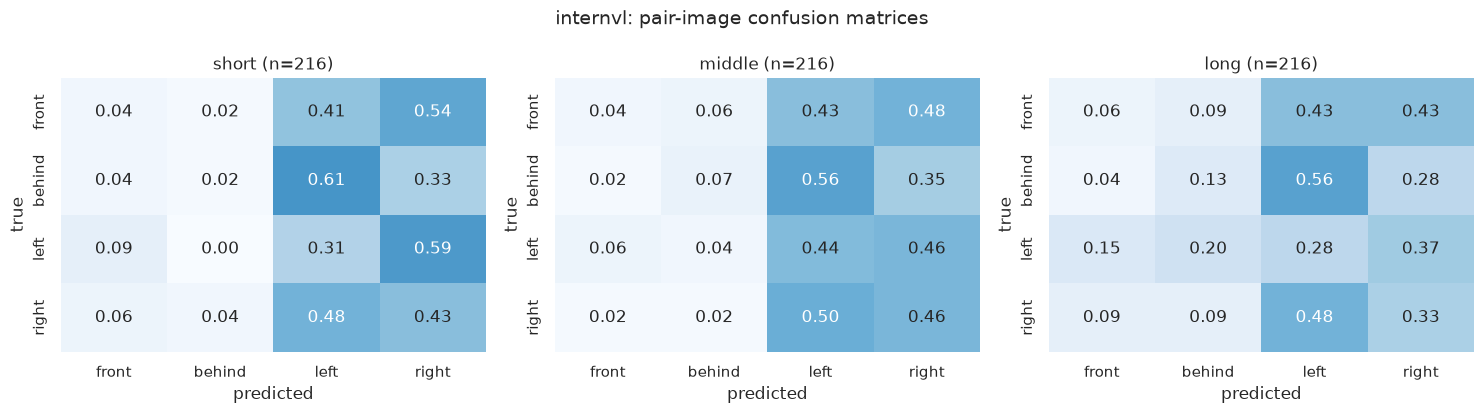

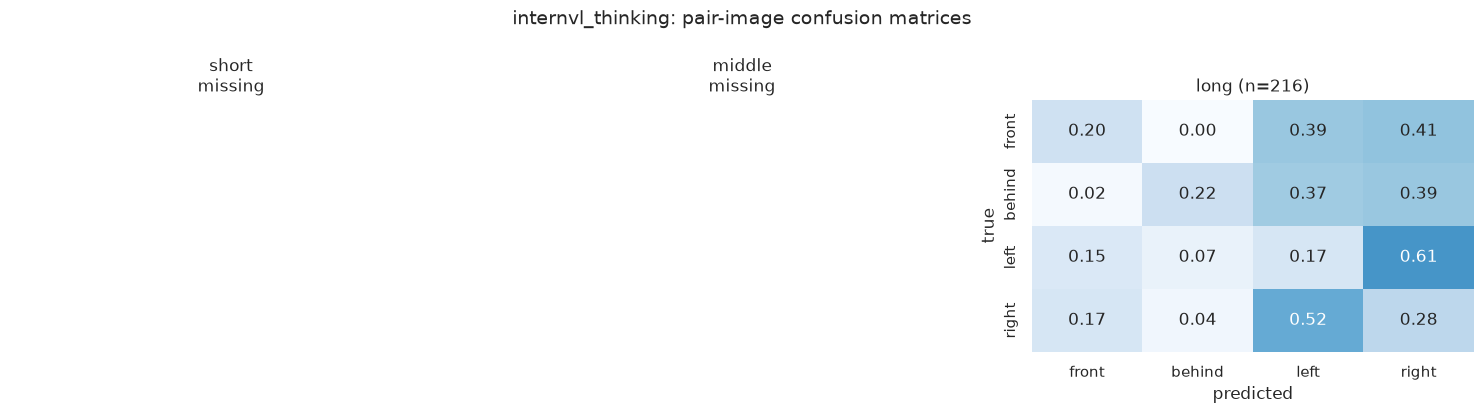

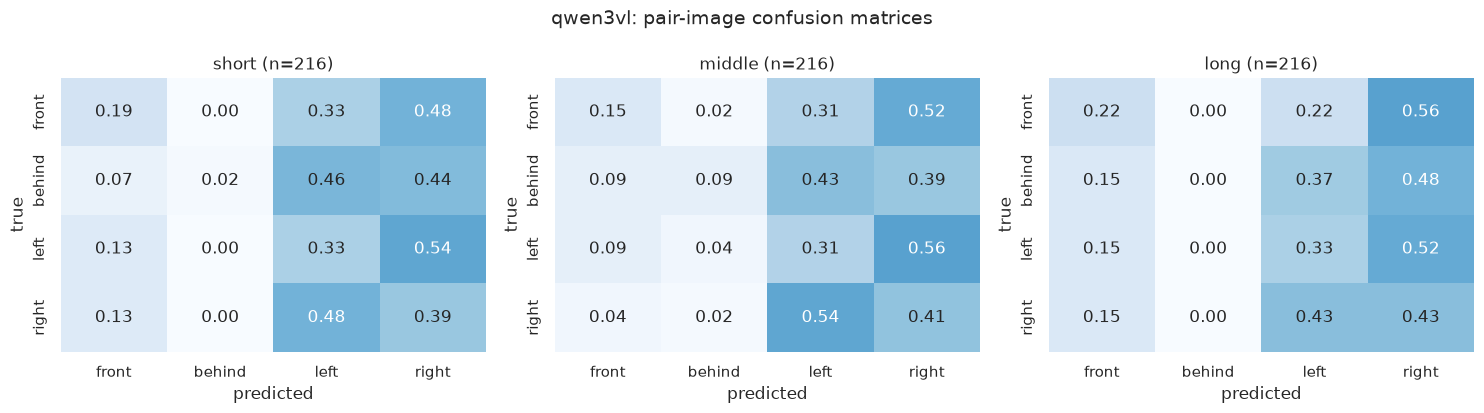

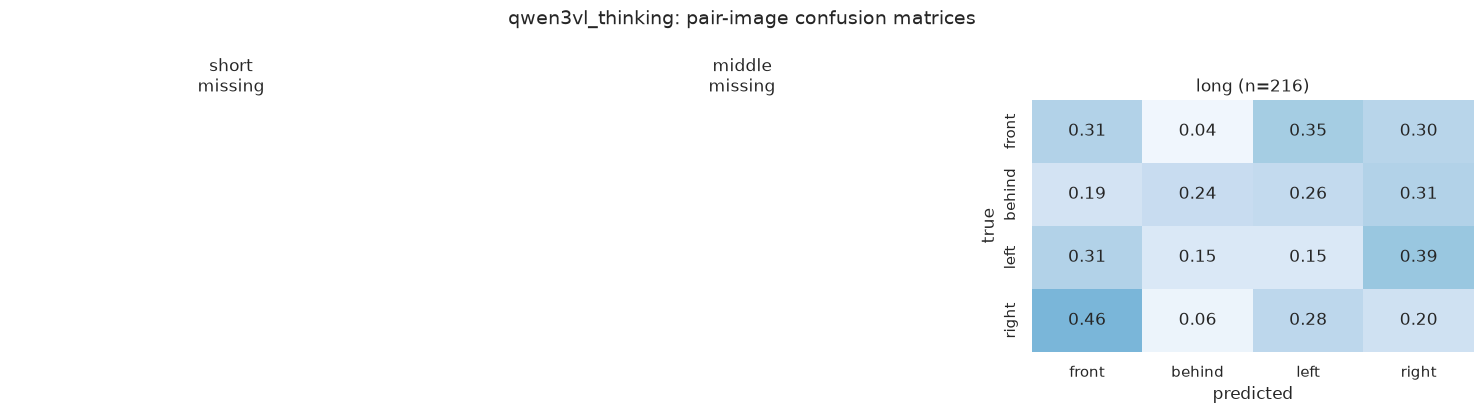

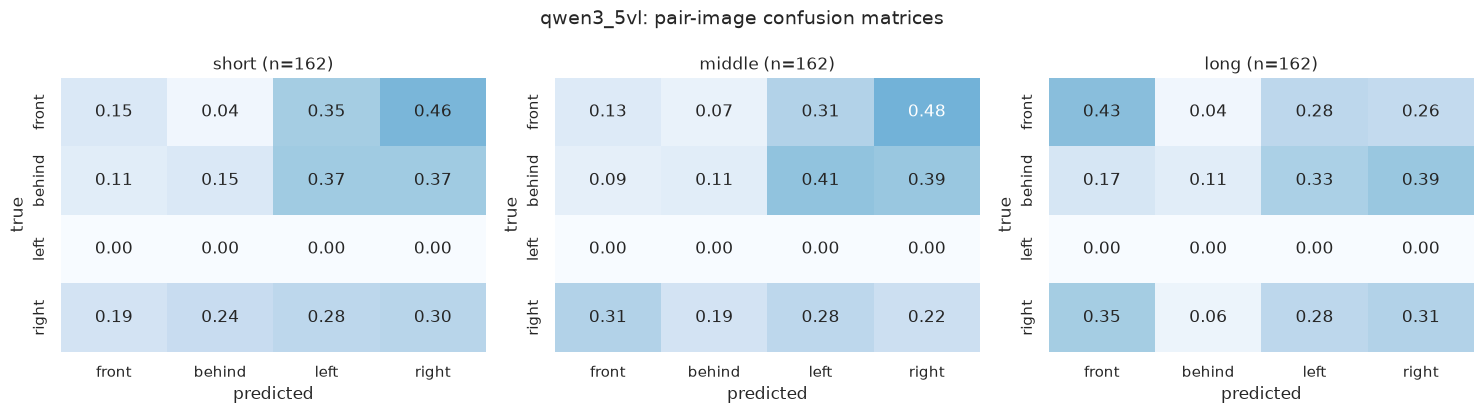

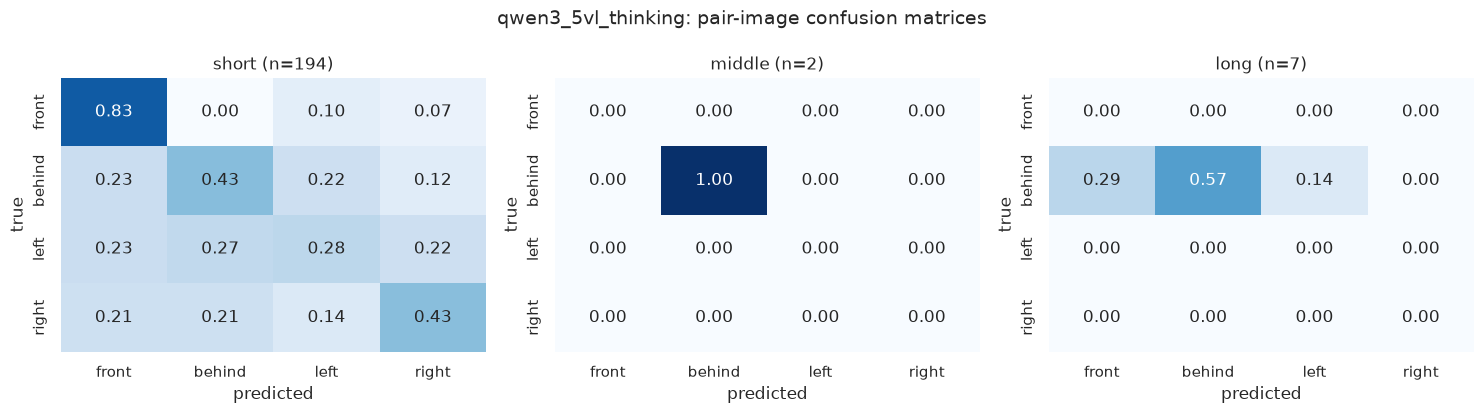

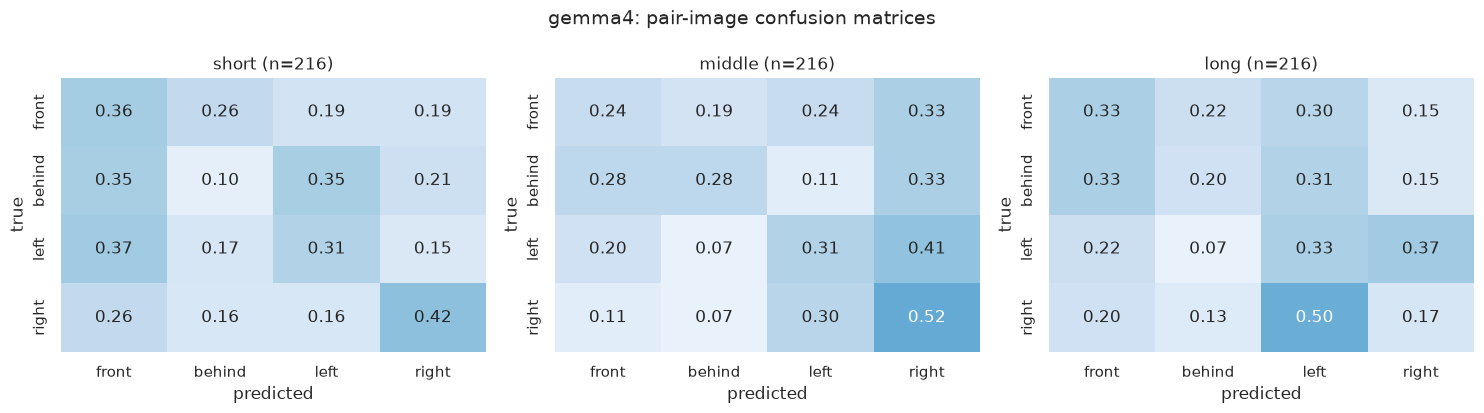

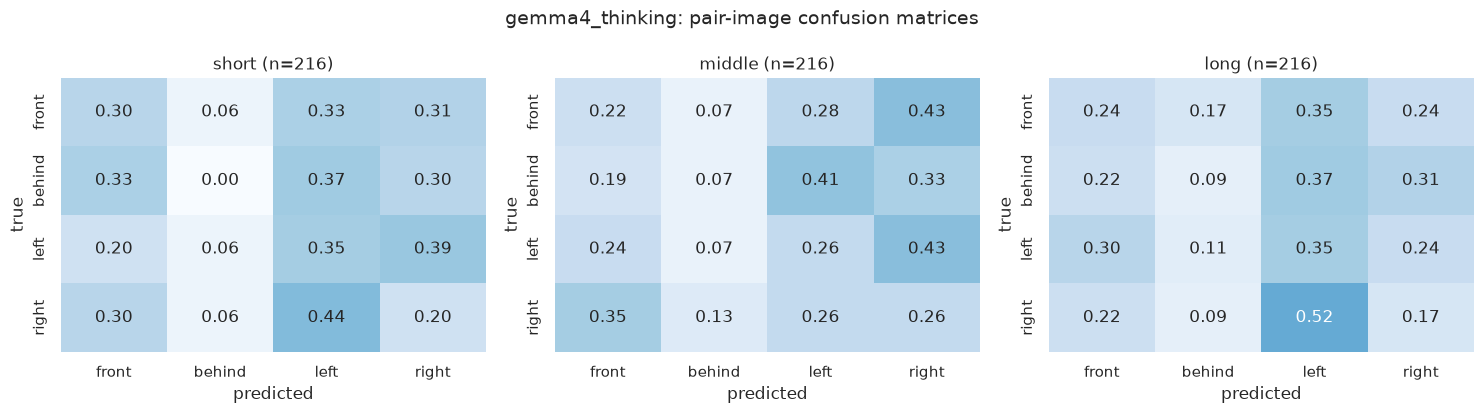

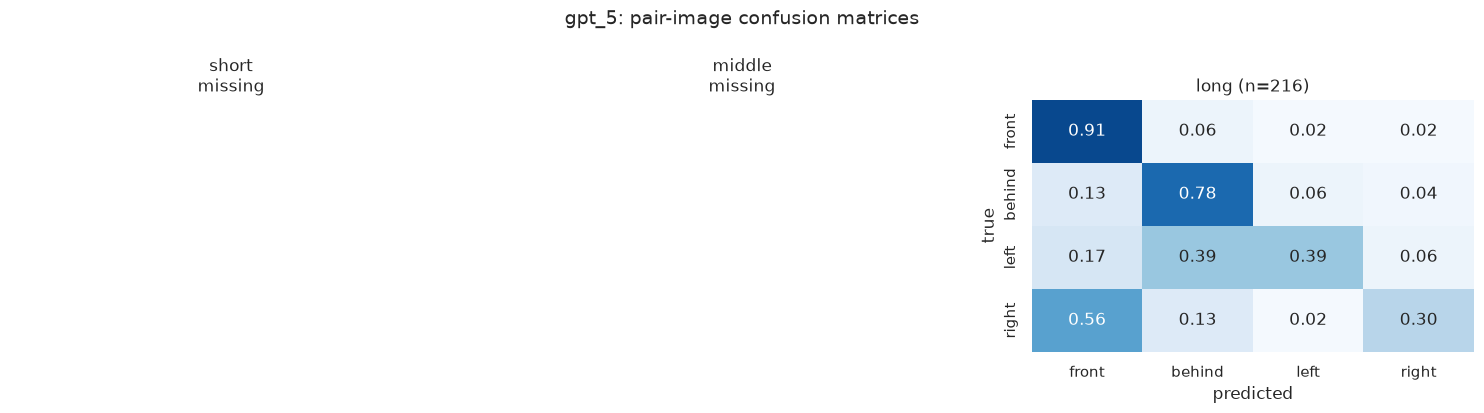

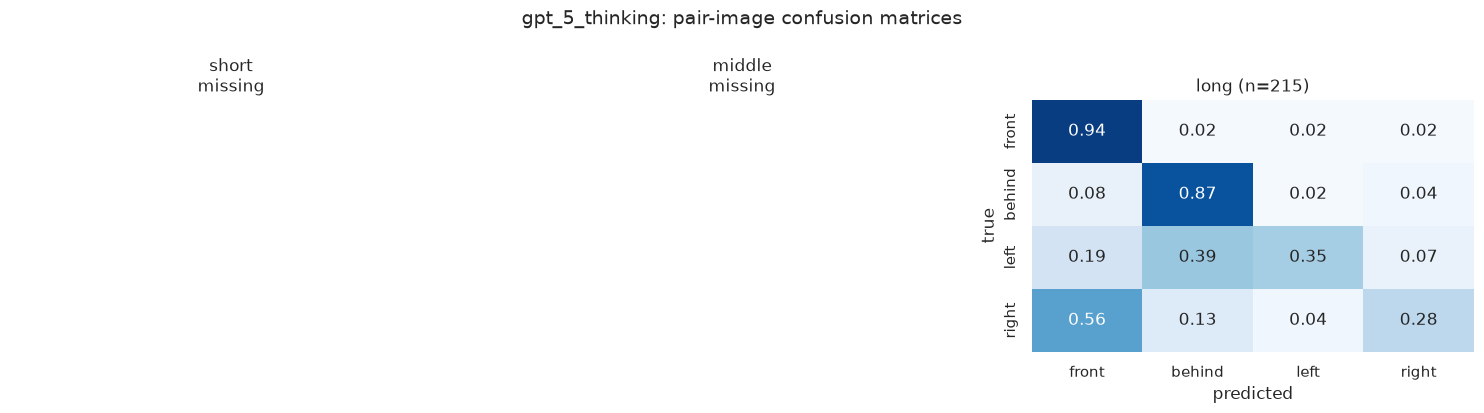

In [5]:
for model in models:
    available = [l for l in LENGTHS if l in all_dfs.get(model, {})]
    if not available:
        continue
    fig, axes = plt.subplots(1, len(LENGTHS), figsize=(5 * len(LENGTHS), 4.2))
    if len(LENGTHS) == 1:
        axes = [axes]
    for ax, length in zip(axes, LENGTHS):
        if length not in all_dfs[model]:
            ax.axis("off")
            ax.set_title(f"{length}\nmissing")
            continue
        df = all_dfs[model][length]
        plot_confusion_on_ax(df, ax, title=f"{length} (n={len(df)})", true_labels=RELATIONS)
    fig.suptitle(f"{model}: pair-image confusion matrices", fontsize=14)
    plt.tight_layout()
    plt.show()

## 5. Accuracy by Camera View Pair

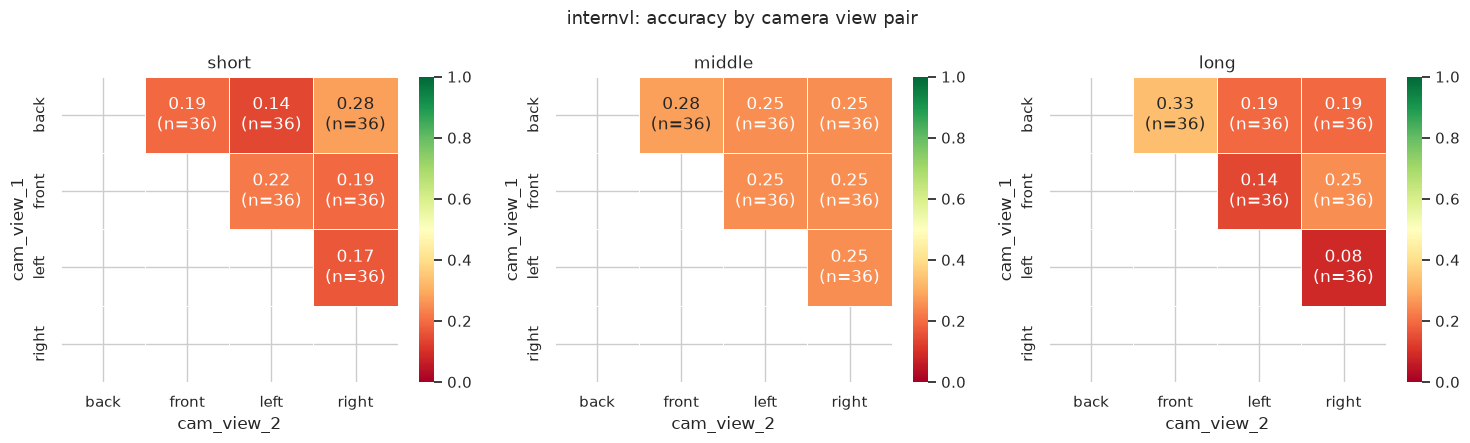

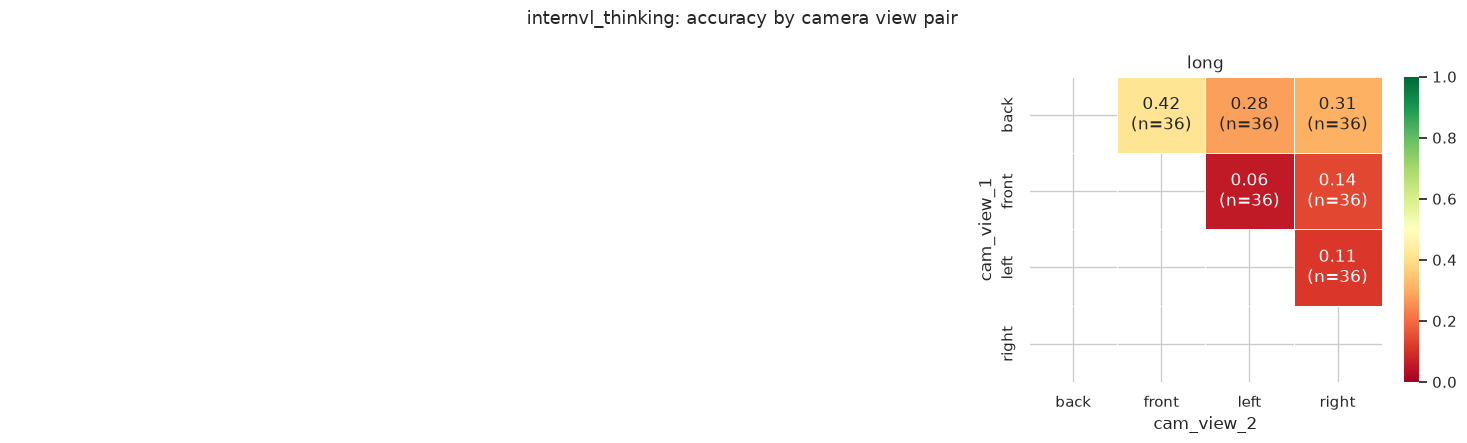

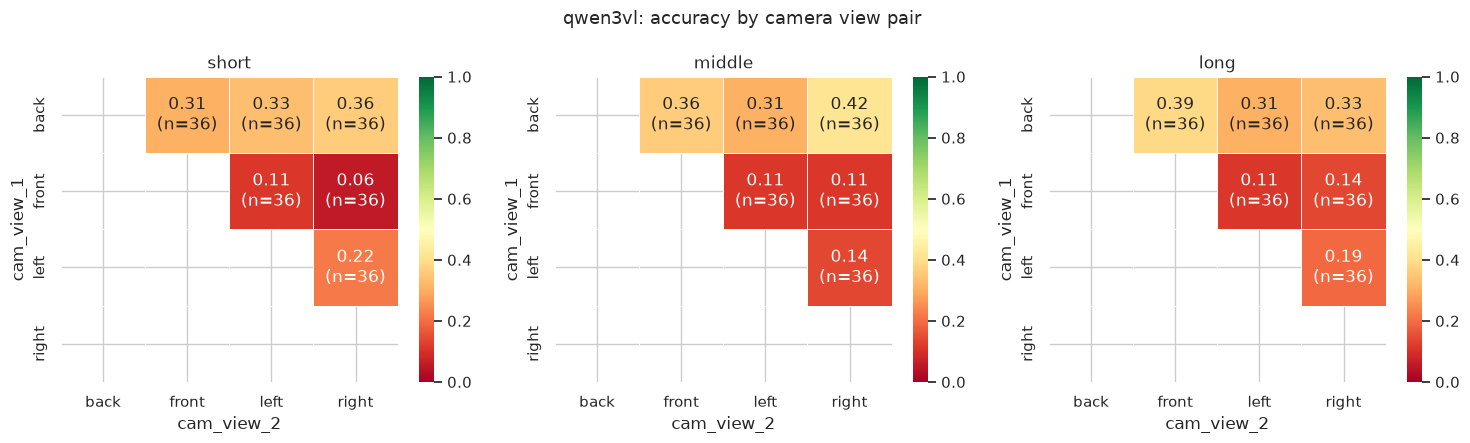

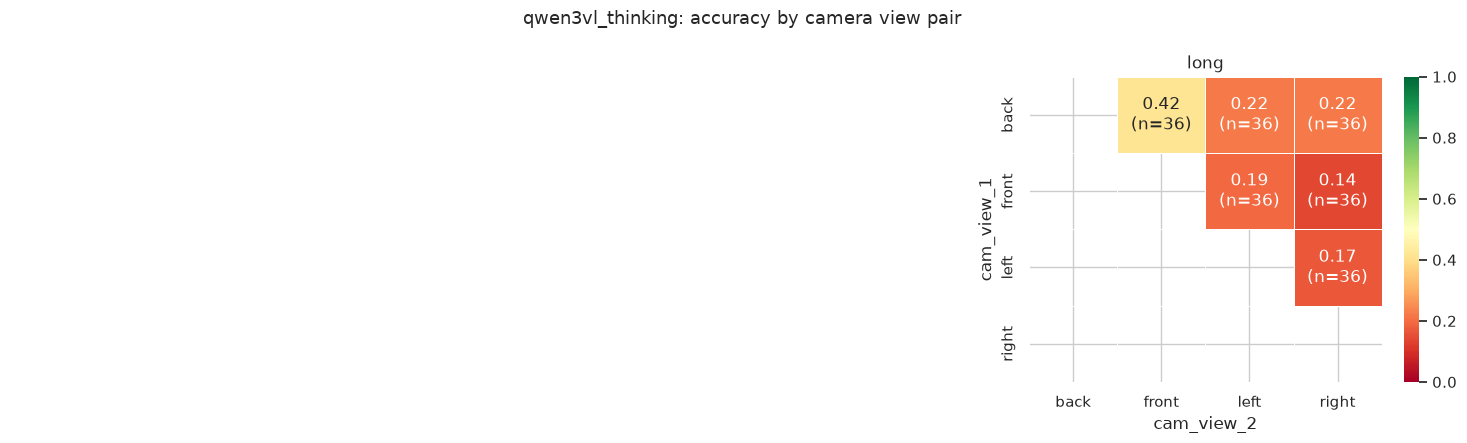

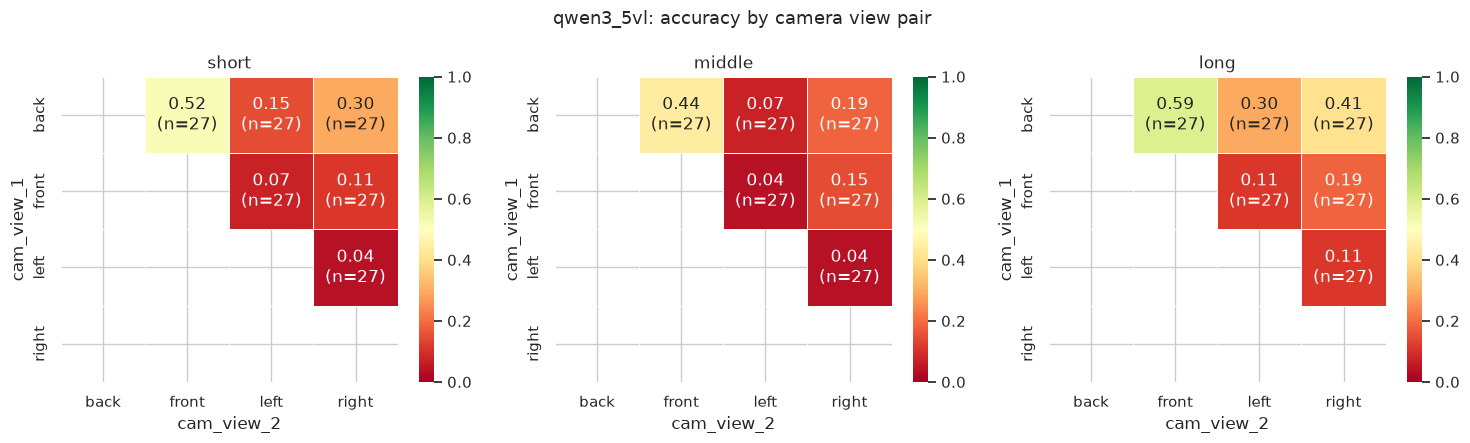

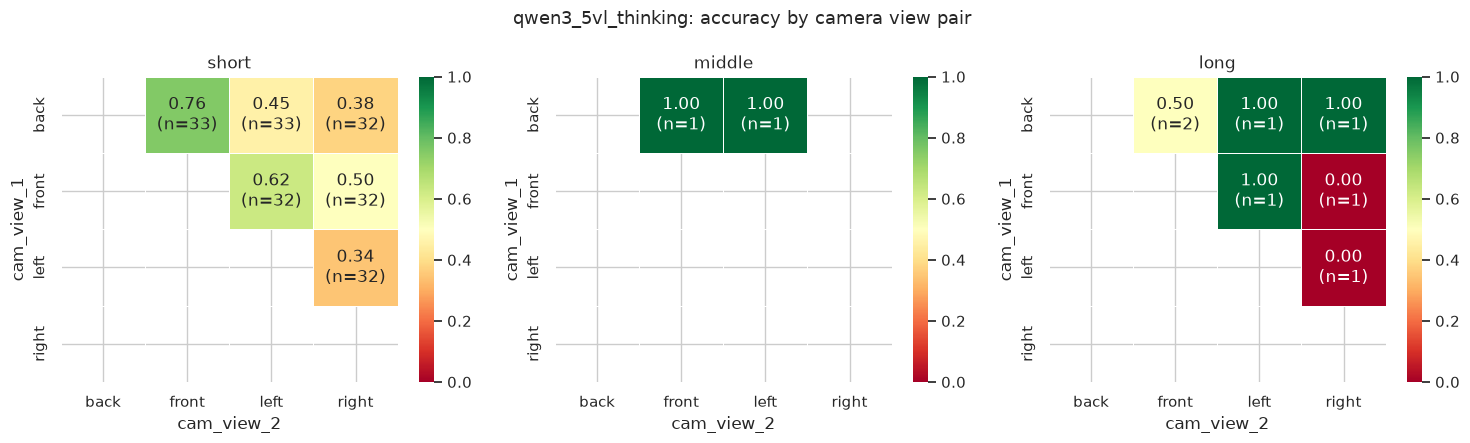

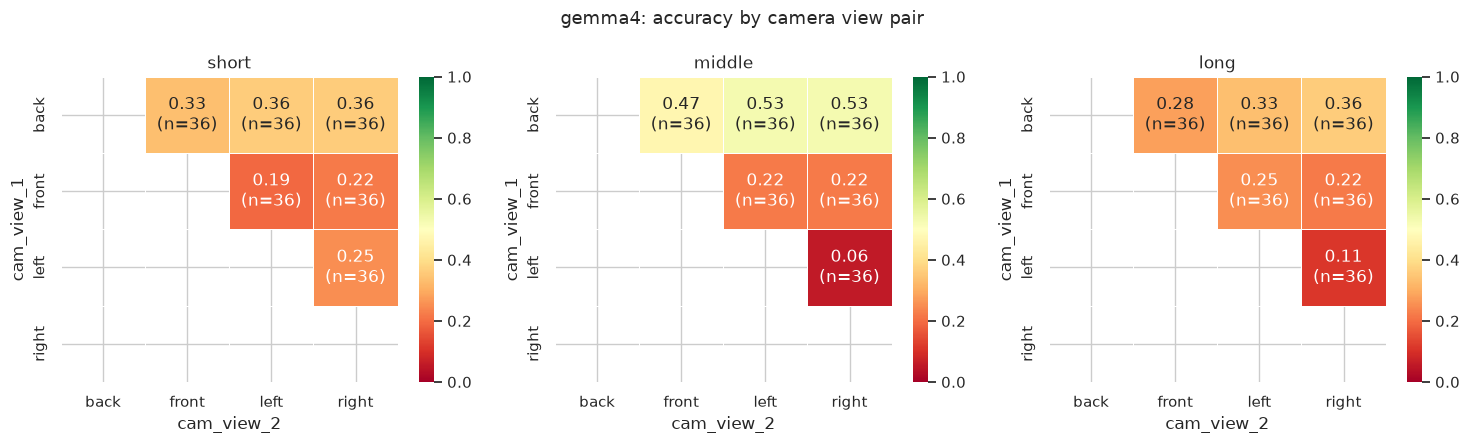

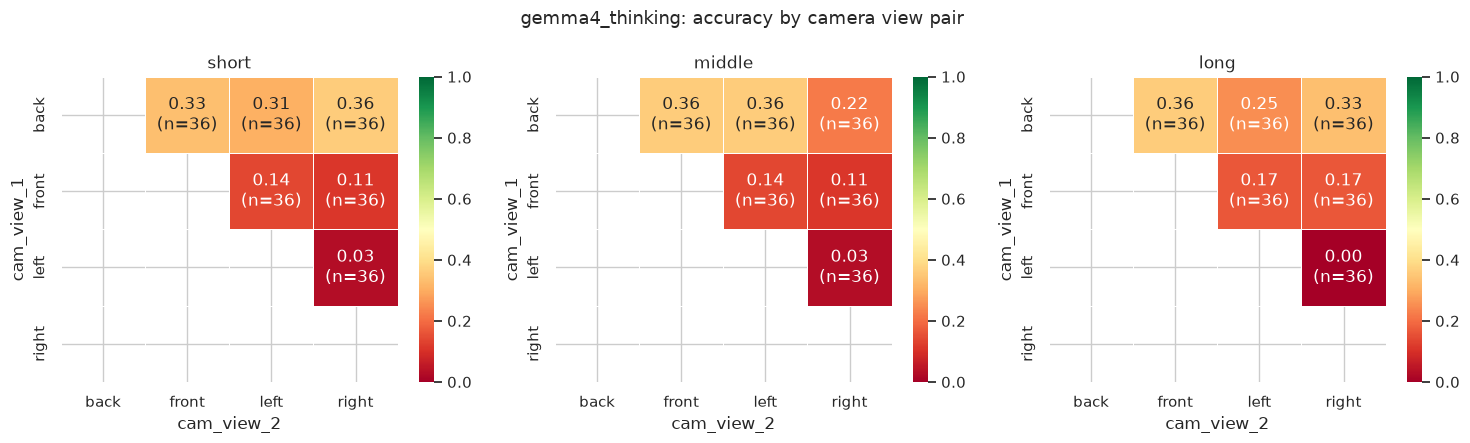

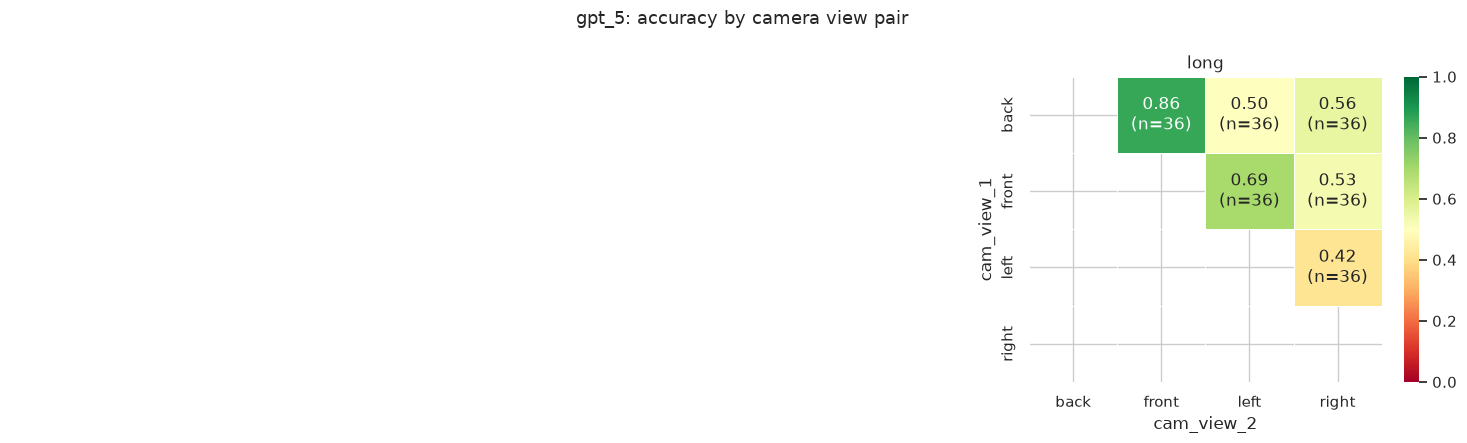

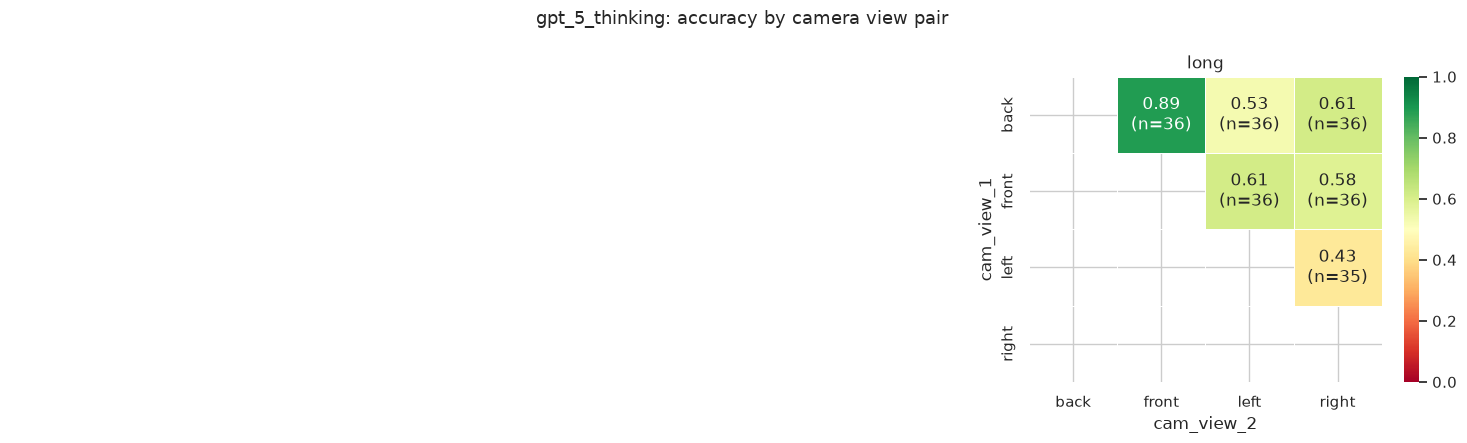

In [6]:
for model in models:
    available = [l for l in LENGTHS if l in all_dfs.get(model, {})]
    if not available:
        continue
    fig, axes = plt.subplots(1, len(LENGTHS), figsize=(5 * len(LENGTHS), 4.5))
    if len(LENGTHS) == 1:
        axes = [axes]
    for ax, length in zip(axes, LENGTHS):
        if length not in all_dfs[model]:
            ax.axis("off")
            continue
        df = all_dfs[model][length]
        acc_matrix = np.full((4, 4), np.nan)
        n_matrix = np.zeros((4, 4), dtype=int)
        for i, v1 in enumerate(VIEW_SHORT):
            for j, v2 in enumerate(VIEW_SHORT):
                if j <= i:
                    continue
                sub = df[(df["view1_short"] == v1) & (df["view2_short"] == v2)]
                if len(sub) == 0:
                    continue
                acc_matrix[i, j] = sub["is_correct"].mean()
                n_matrix[i, j] = len(sub)
        annot = np.empty((4, 4), dtype=object)
        annot[:] = ""
        for i in range(4):
            for j in range(4):
                if not np.isnan(acc_matrix[i, j]):
                    annot[i, j] = f"{acc_matrix[i, j]:.2f}\n(n={n_matrix[i, j]})"
        mask_lower = np.tril(np.ones((4, 4), dtype=bool))
        sns.heatmap(acc_matrix, ax=ax, annot=annot, fmt="", mask=mask_lower, cmap="RdYlGn", vmin=0, vmax=1, linewidths=0.5, xticklabels=VIEW_SHORT, yticklabels=VIEW_SHORT, cbar=True)
        ax.set_title(length)
        ax.set_xlabel("cam_view_2")
        ax.set_ylabel("cam_view_1")
    fig.suptitle(f"{model}: accuracy by camera view pair", fontsize=13)
    plt.tight_layout()
    plt.show()

## 6. Prediction Alignment: Correct Relation vs Camera Perspectives

For each view pair, compare whether predictions match the true person-centric relation, the apparent relation from image 1, or the apparent relation from image 2.

,model,length,view_pair,n,correct_relation,camera_perspective_img1,camera_perspective_img2
0,gemma4,long,back x front,36,0.278,0.278,0.417
1,gemma4,long,back x left,36,0.333,0.417,0.194
2,gemma4,long,back x right,36,0.361,0.444,0.194
3,gemma4,long,front x left,36,0.250,0.500,0.167
4,gemma4,long,front x right,36,0.222,0.528,0.194
5,gemma4,long,left x right,36,0.111,0.444,0.222
6,gemma4,middle,back x front,36,0.472,0.639,0.278
7,gemma4,middle,back x left,36,0.528,0.528,0.278
8,gemma4,middle,back x right,36,0.528,0.556,0.278
9,gemma4,middle,front x left,36,0.222,0.694,0.222


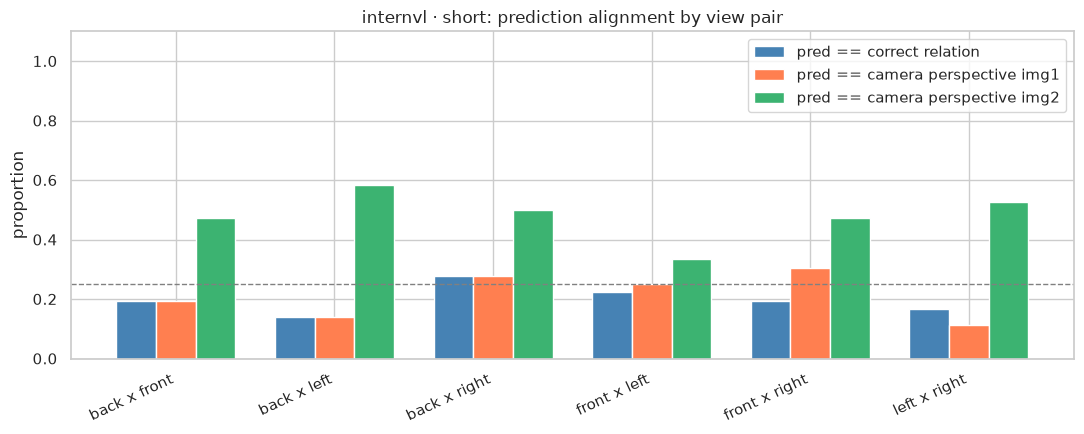

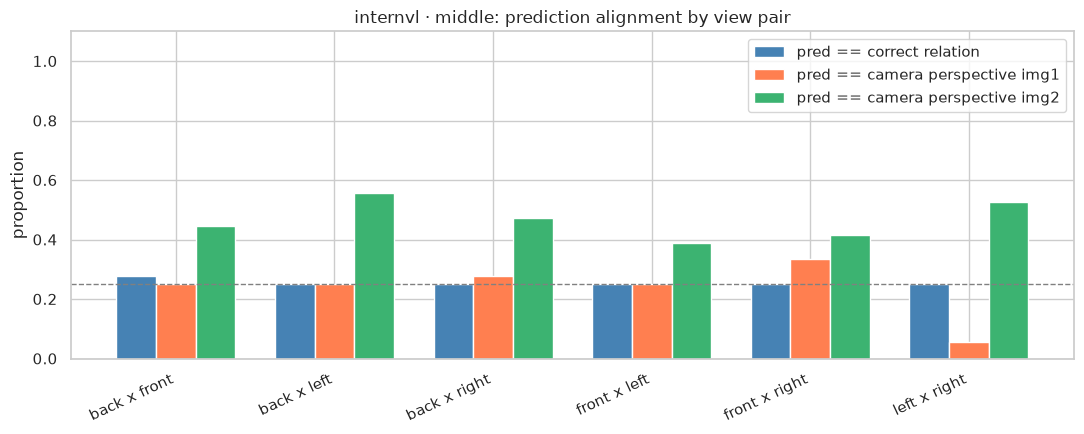

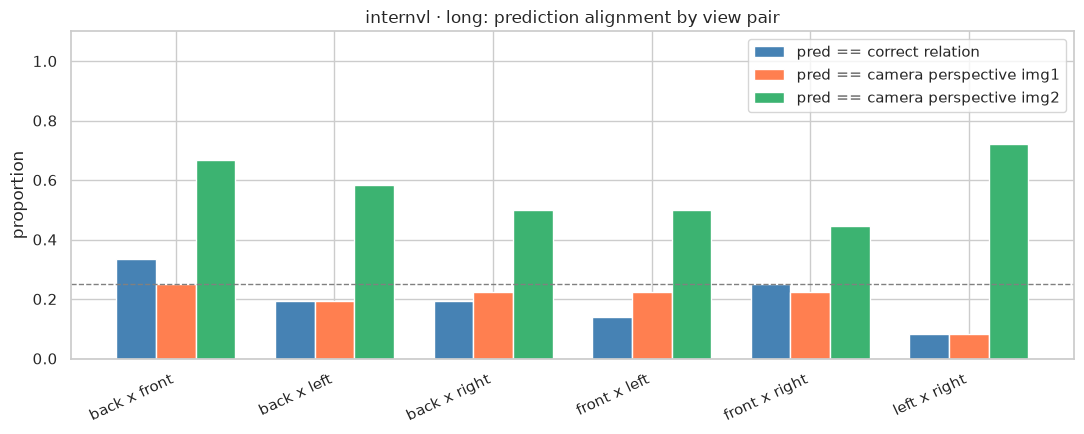

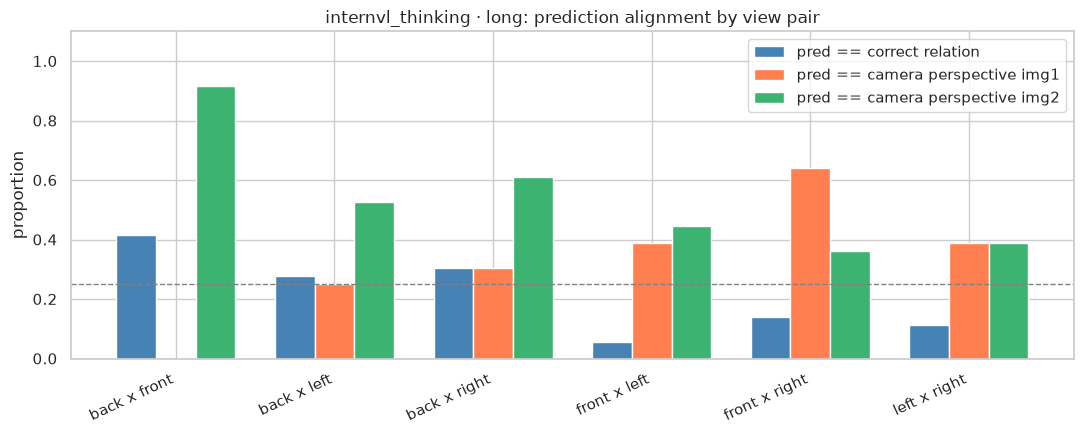

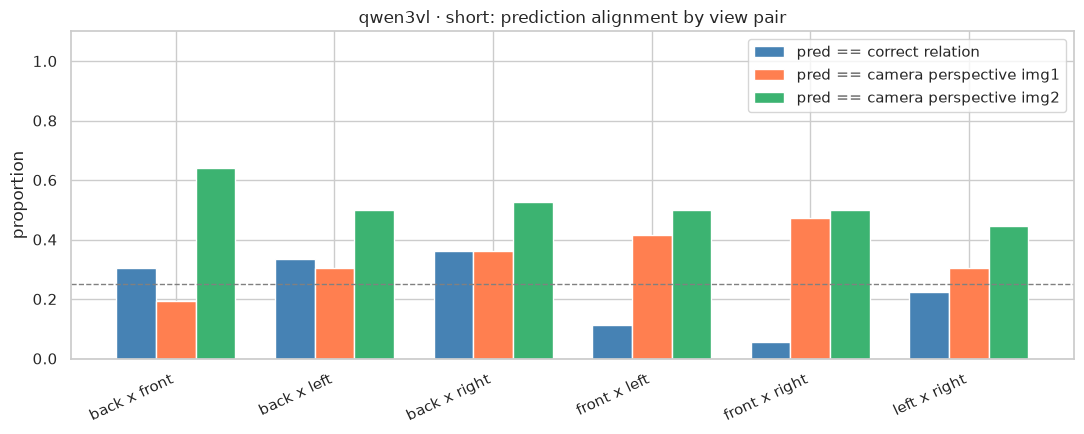

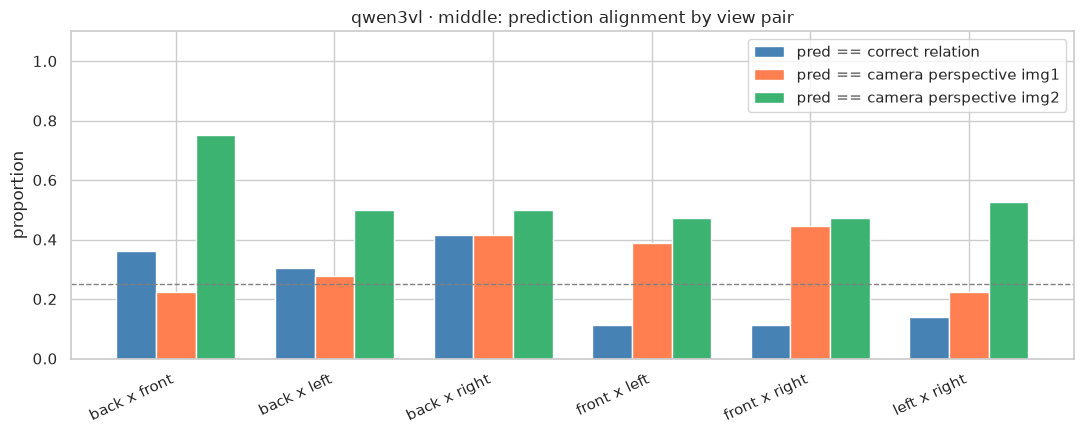

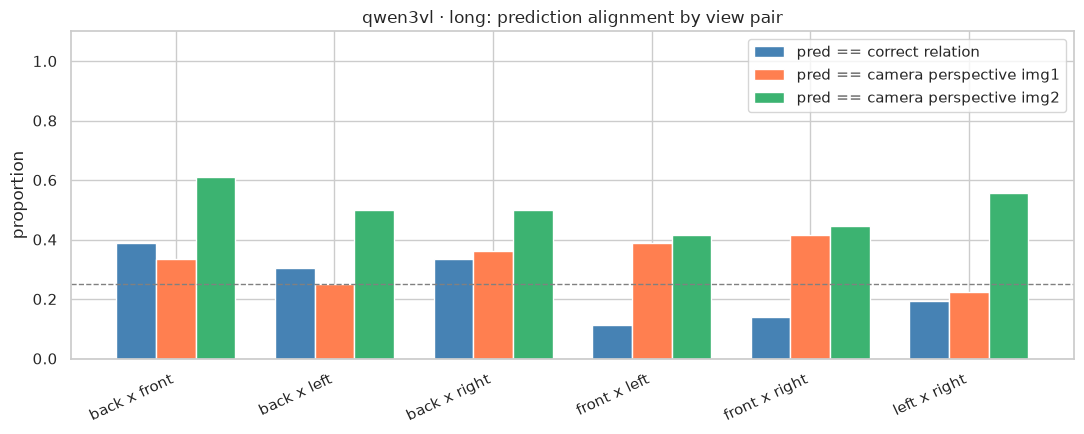

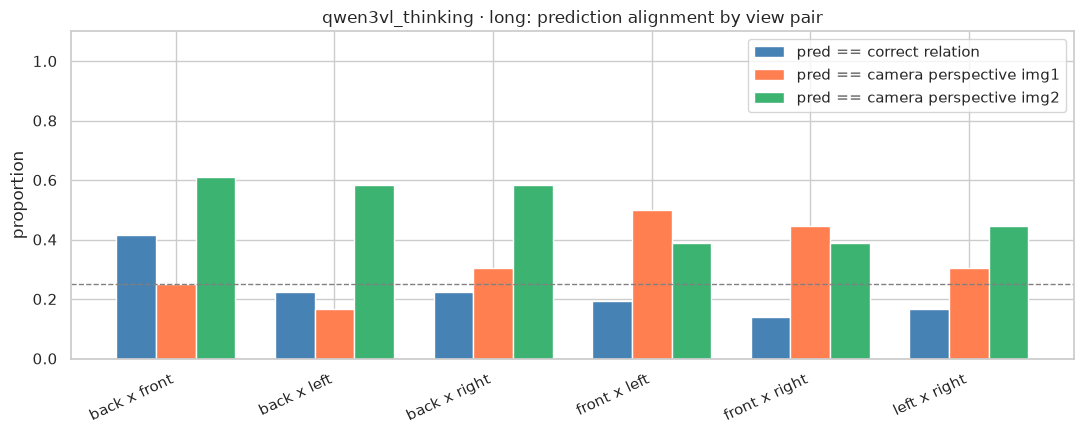

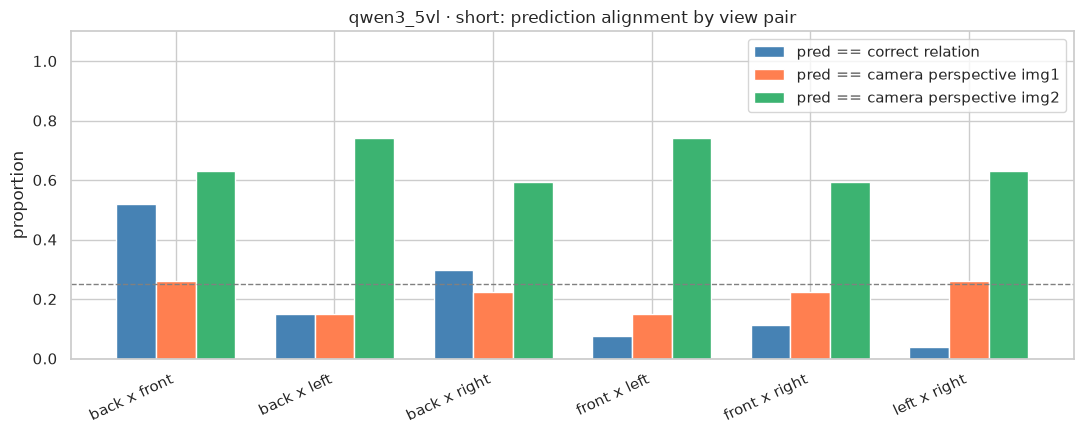

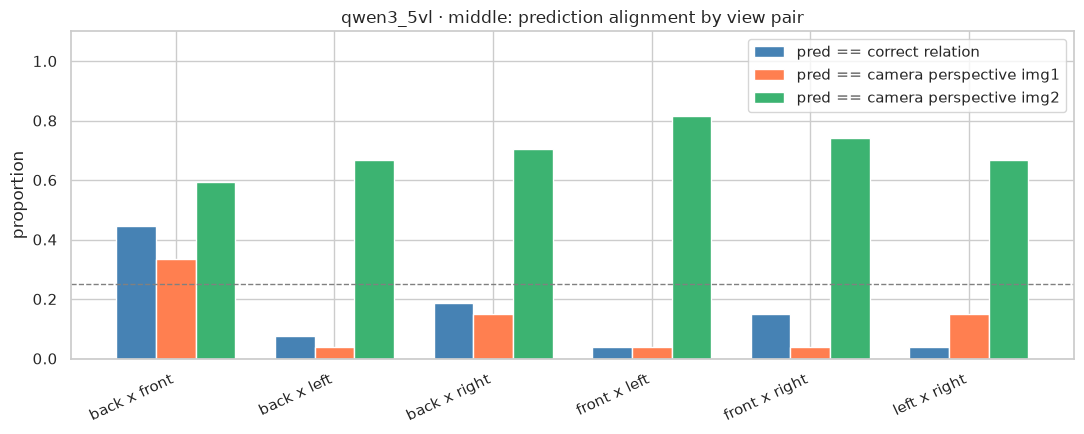

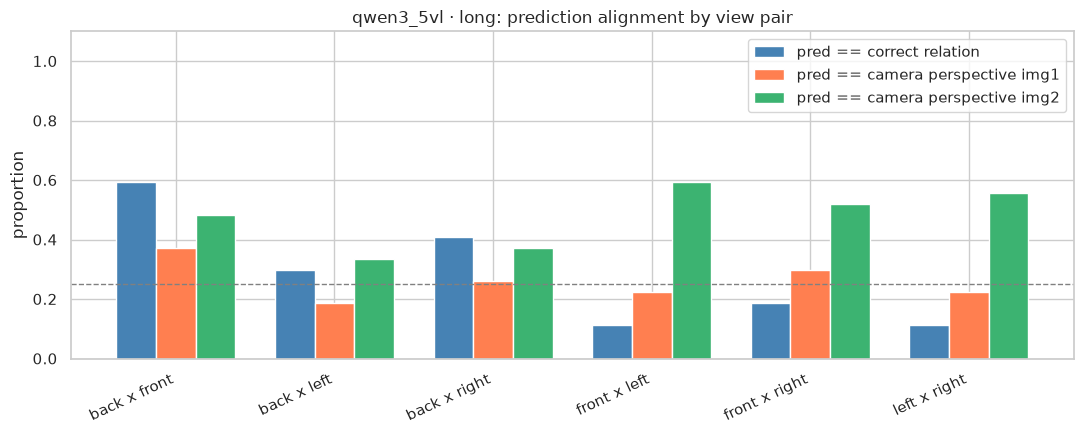

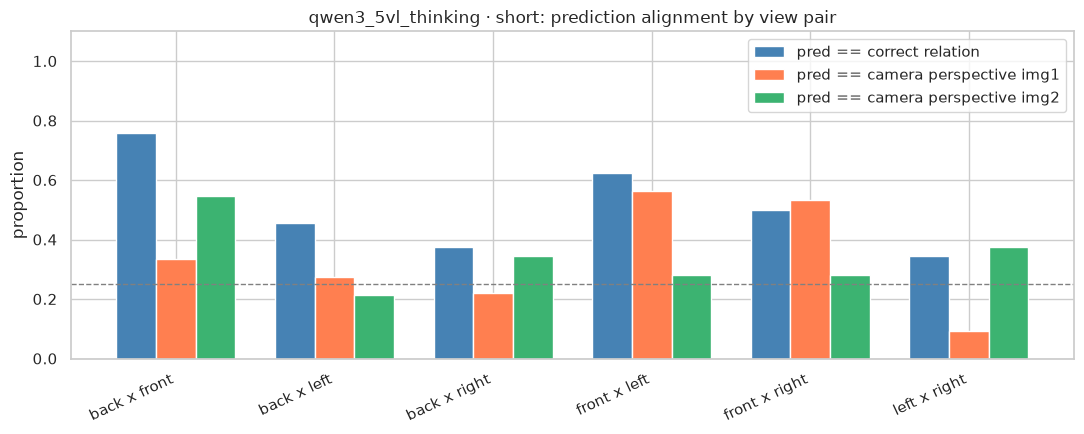

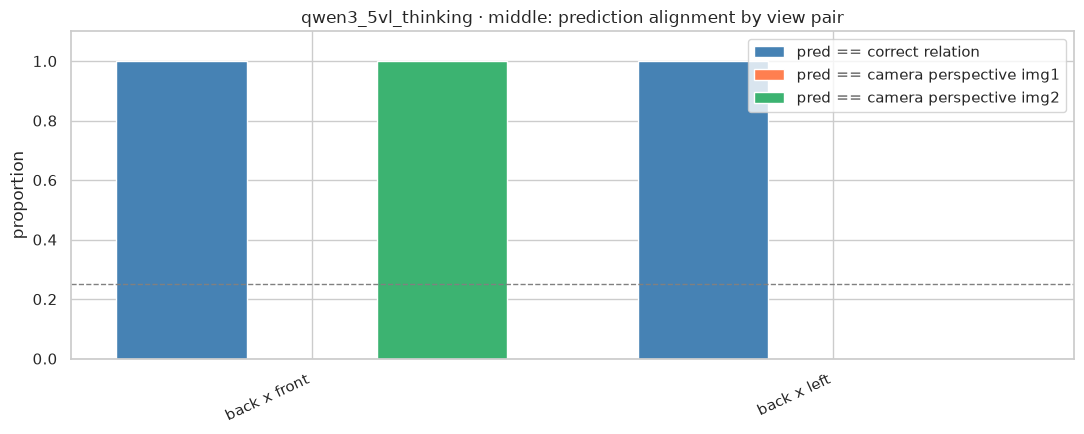

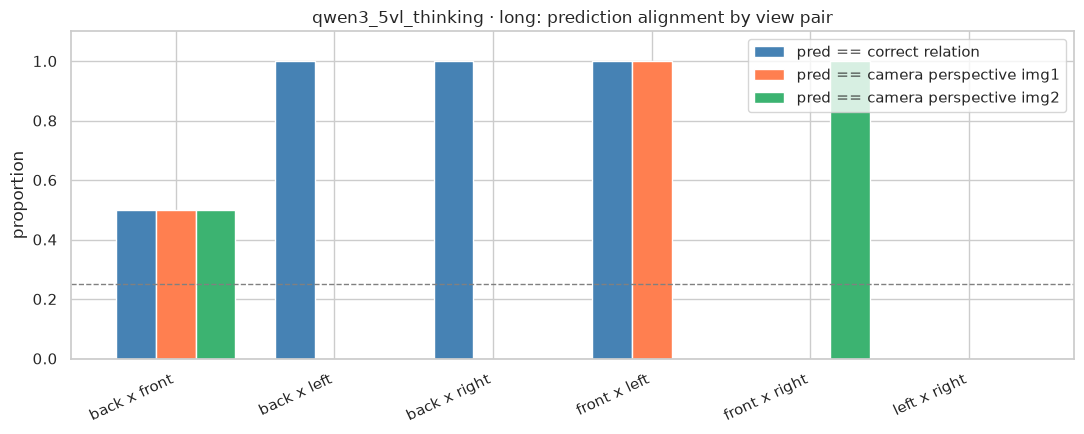

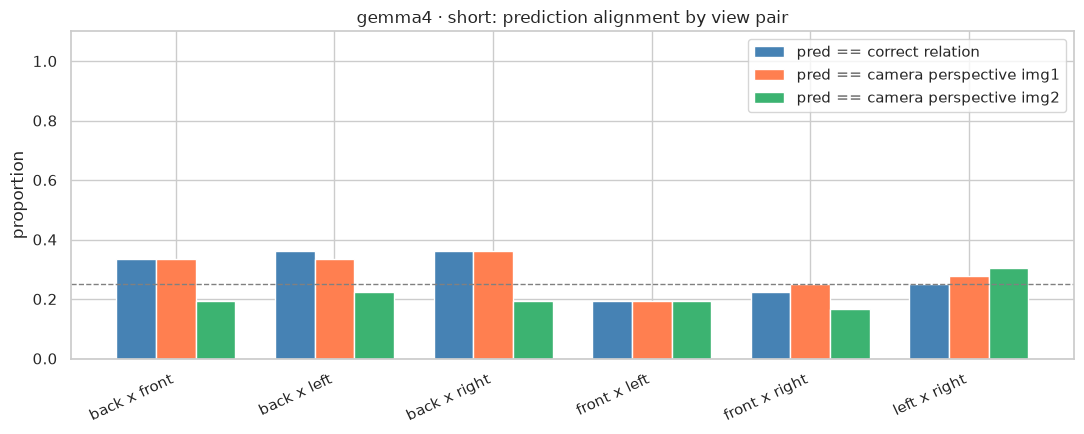

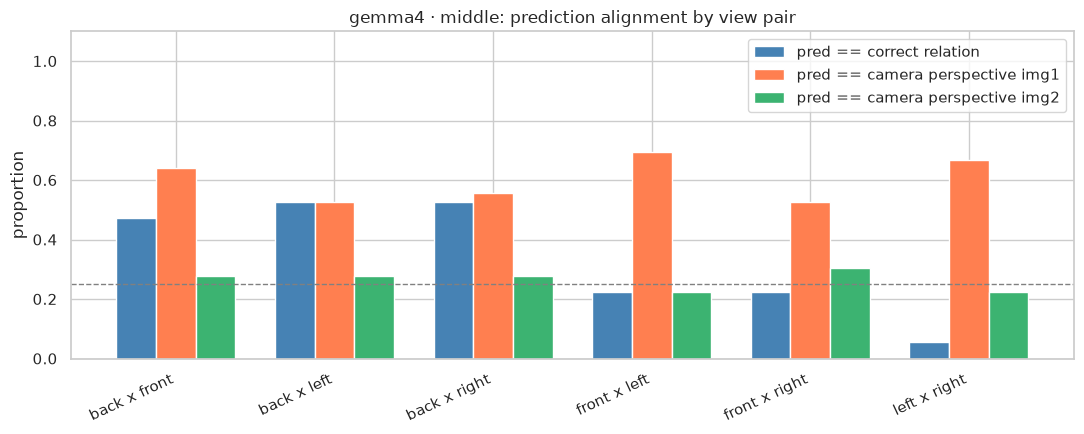

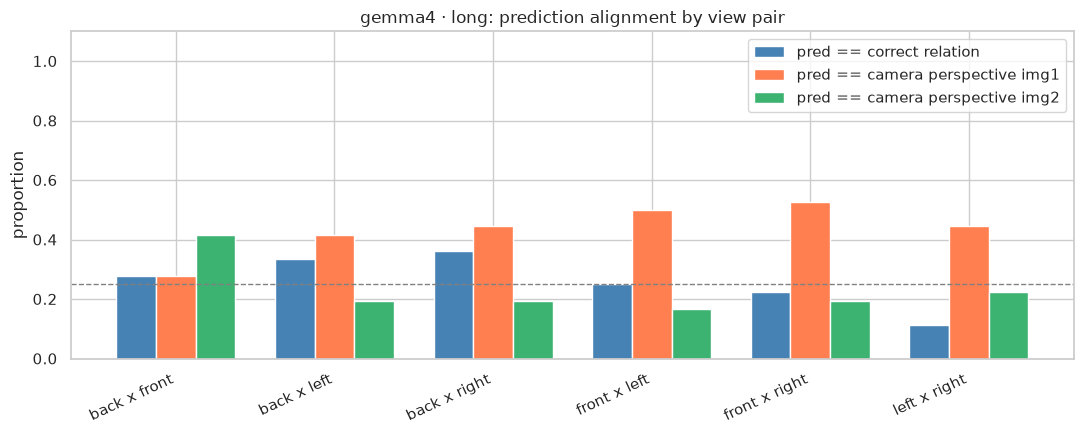

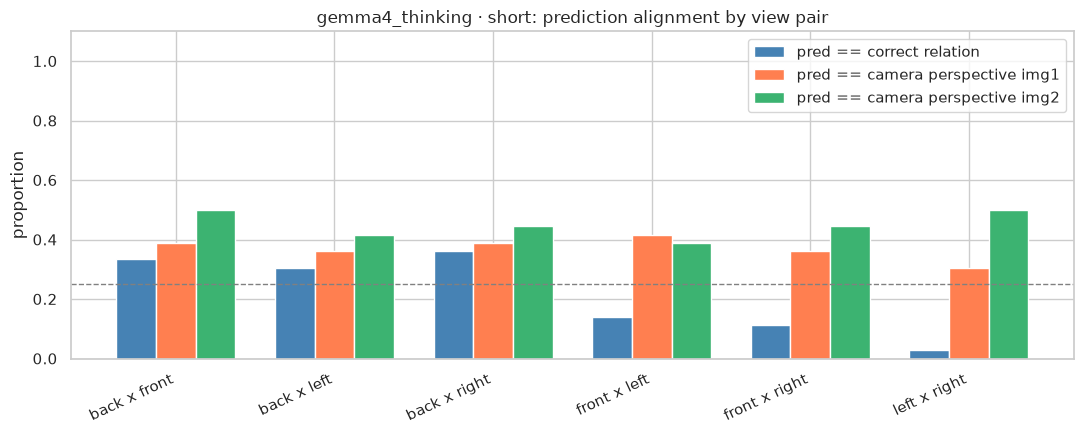

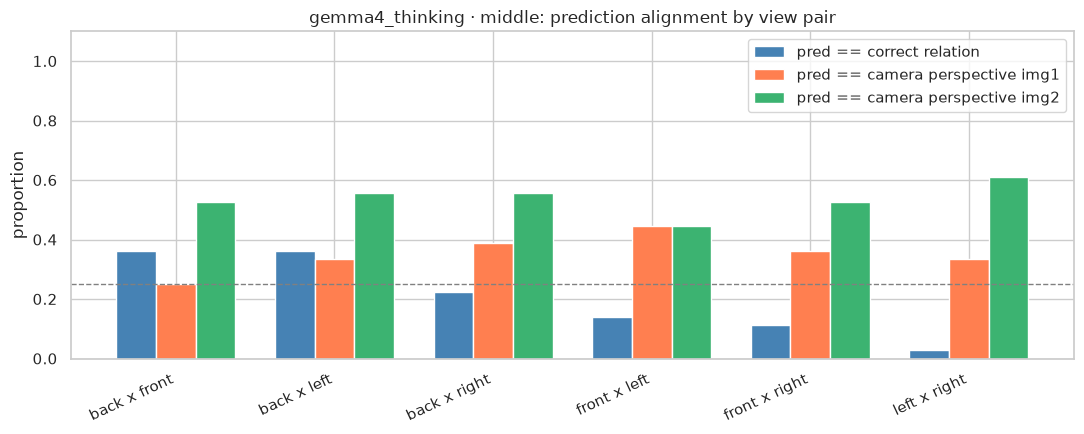

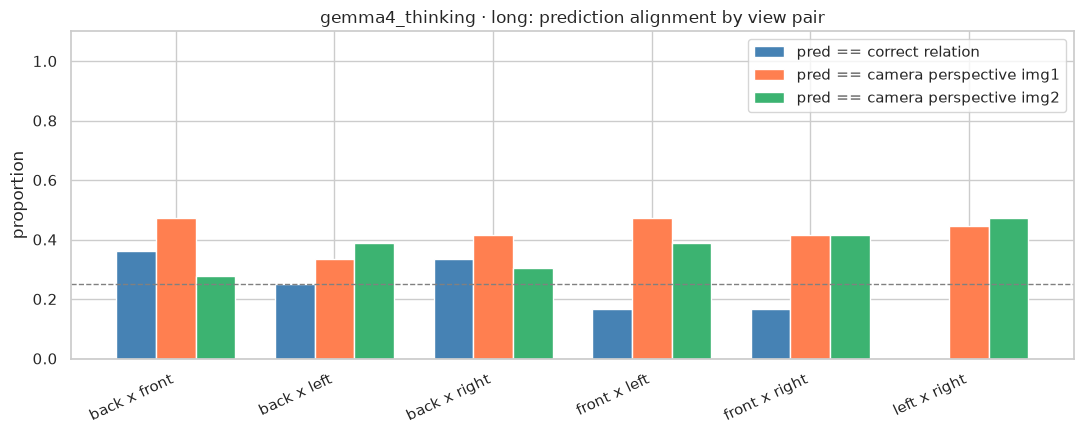

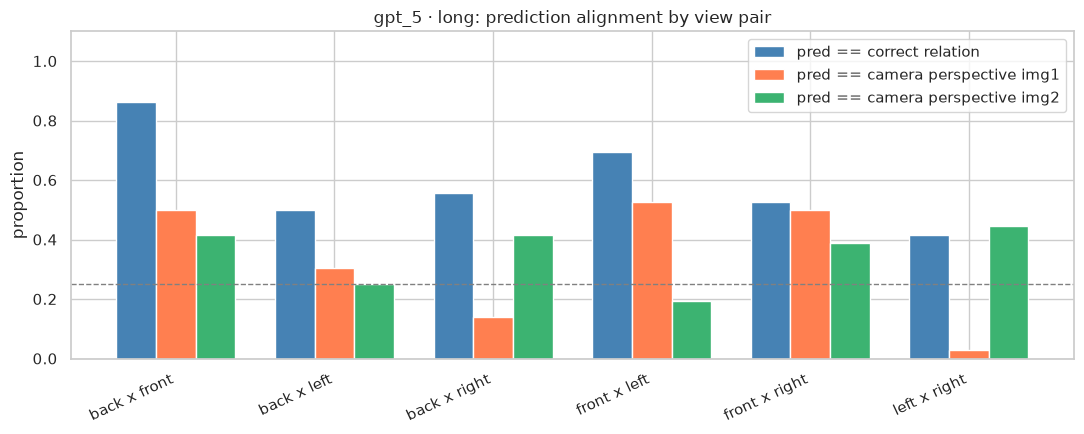

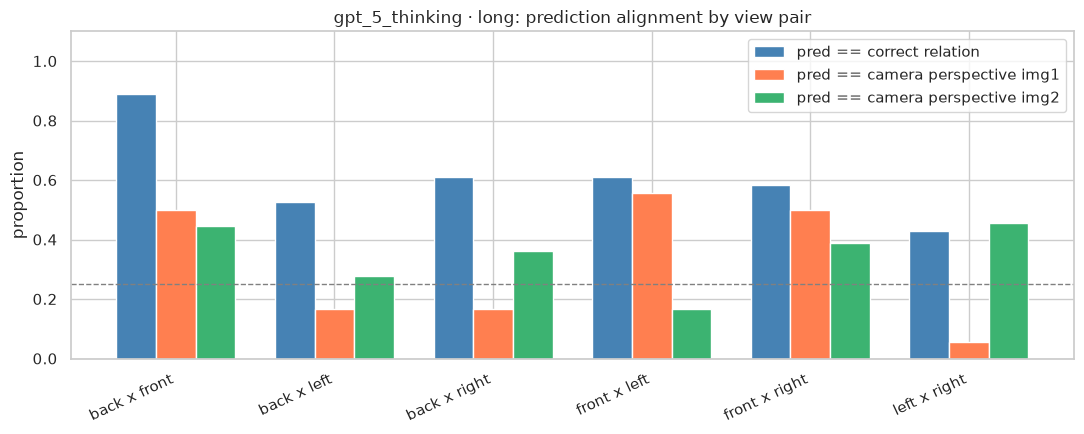

In [7]:
alignment_rows = []
for model, by_length in all_dfs.items():
    for length, df in by_length.items():
        for v1, v2 in VIEW_PAIRS_ORDERED:
            sub = df[(df["view1_short"] == v1) & (df["view2_short"] == v2)].copy()
            if len(sub) == 0:
                continue
            alignment_rows.append({
                "model": model,
                "length": length,
                "view_pair": f"{v1} x {v2}",
                "n": len(sub),
                "correct_relation": (sub["pred_relation"] == sub["correct_relation"]).mean(),
                "camera_perspective_img1": (sub["pred_relation"] == sub["cam_perspective_1"]).mean(),
                "camera_perspective_img2": (sub["pred_relation"] == sub["cam_perspective_2"]).mean(),
            })
alignment_df = pd.DataFrame(alignment_rows)
if len(alignment_df):
    display(alignment_df.sort_values(["model", "length", "view_pair"]).round(3).reset_index(drop=True))

    for model in models:
        for length in LENGTHS:
            sub = alignment_df[(alignment_df["model"] == model) & (alignment_df["length"] == length)]
            if len(sub) == 0:
                continue
            sub = sub.set_index("view_pair").reindex([f"{a} x {b}" for a, b in VIEW_PAIRS_ORDERED]).dropna(how="all")
            fig, ax = plt.subplots(figsize=(11, 4.5))
            x = np.arange(len(sub))
            w = 0.25
            ax.bar(x - w, sub["correct_relation"], w, label="pred == correct relation", color="steelblue")
            ax.bar(x, sub["camera_perspective_img1"], w, label="pred == camera perspective img1", color="coral")
            ax.bar(x + w, sub["camera_perspective_img2"], w, label="pred == camera perspective img2", color="mediumseagreen")
            ax.axhline(0.25, color="gray", linestyle="--", linewidth=1)
            ax.set_ylim(0, 1.1)
            ax.set_xticks(x)
            ax.set_xticklabels(sub.index, rotation=25, ha="right")
            ax.set_ylabel("proportion")
            ax.set_title(f"{model} · {length}: prediction alignment by view pair")
            ax.legend(loc="upper right")
            plt.tight_layout()
            plt.show()

## 7. Pair vs Single-image Accuracy

When the matching single-image CSV exists, this compares single-image and pair-image accuracy by true relation.

,model,length,relation,single_n,pair_n,single_acc,pair_acc,delta_pair_minus_single
0,gemma4,long,behind,36,54,0.028,0.204,0.176
1,gemma4,long,front,36,54,0.250,0.333,0.083
2,gemma4,long,left,36,54,0.333,0.333,0.000
3,gemma4,long,right,36,54,0.306,0.167,-0.139
4,gemma4,middle,behind,36,54,0.167,0.278,0.111
5,gemma4,middle,front,36,54,0.333,0.241,-0.093
6,gemma4,middle,left,36,54,0.361,0.315,-0.046
7,gemma4,middle,right,36,54,0.361,0.519,0.157
8,gemma4,short,behind,36,54,0.167,0.093,-0.074
9,gemma4,short,front,36,54,0.194,0.352,0.157


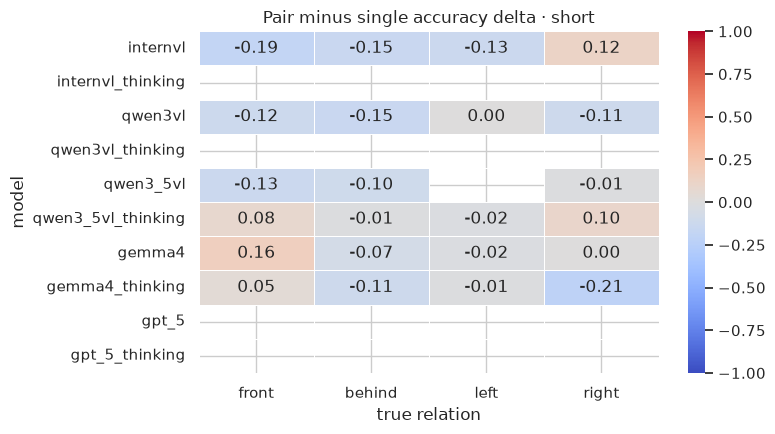

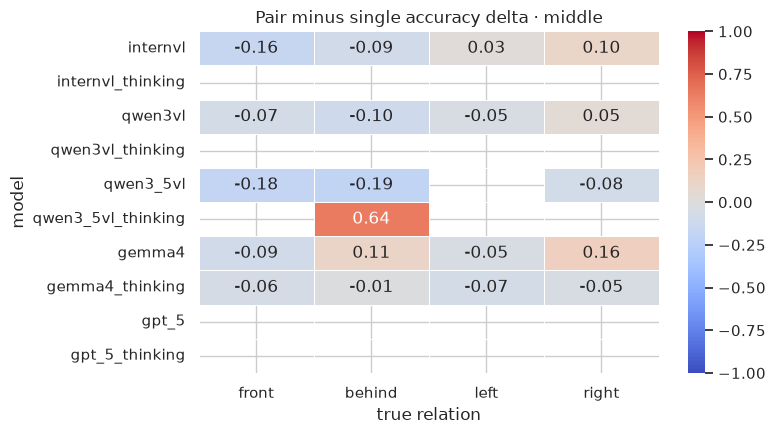

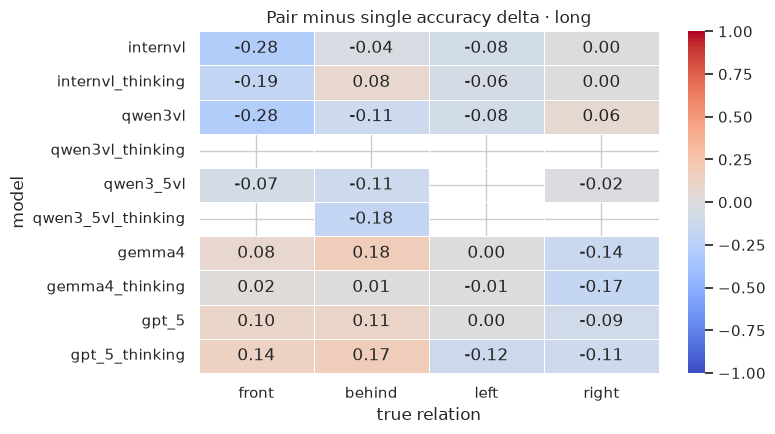

In [8]:
single_files = {}
for path in sorted(glob.glob(os.path.join(BASE_DIR, "mcq_*.csv"))):
    parsed = parse_result_filename(path, prefix="mcq")
    if parsed is None:
        continue
    model, length = parsed
    single_files[(model, length)] = path

comparison_rows = []
for model, by_length in all_dfs.items():
    for length, df_pair in by_length.items():
        single_path = single_files.get((model, length))
        if single_path is None:
            continue
        df_single = load_single(single_path)
        if len(df_single) == 0:
            continue
        for rel in RELATIONS:
            s_sub = df_single[df_single["correct_relation"] == rel]
            p_sub = df_pair[df_pair["correct_relation"] == rel]
            comparison_rows.append({
                "model": model,
                "length": length,
                "relation": rel,
                "single_n": len(s_sub),
                "pair_n": len(p_sub),
                "single_acc": s_sub["is_correct"].mean() if len(s_sub) else np.nan,
                "pair_acc": p_sub["is_correct"].mean() if len(p_sub) else np.nan,
            })
comparison_df = pd.DataFrame(comparison_rows)
if len(comparison_df):
    comparison_df["delta_pair_minus_single"] = comparison_df["pair_acc"] - comparison_df["single_acc"]
    display(comparison_df.sort_values(["model", "length", "relation"]).round(3).reset_index(drop=True))

    for length in LENGTHS:
        sub = comparison_df[comparison_df["length"] == length]
        if len(sub) == 0:
            continue
        pivot = sub.pivot_table(index="model", columns="relation", values="delta_pair_minus_single").reindex(index=models, columns=RELATIONS)
        fig, ax = plt.subplots(figsize=(8, max(3, 0.45 * len(models))))
        sns.heatmap(pivot, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax)
        ax.set_title(f"Pair minus single accuracy delta · {length}")
        ax.set_xlabel("true relation")
        ax.set_ylabel("model")
        plt.tight_layout()
        plt.show()